In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [3]:

df = pd.read_csv("final_gdp_co2_dataset.csv")

print("Dataset shape (rows, columns):", df.shape)
print("\nColumn data types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())



Dataset shape (rows, columns): (150, 5)

Column data types:
 country                           object
year                               int64
gdp_per_capita_usd               float64
co2_emissions_per_capita_tons    float64
gdp_per_capita_sq                float64
dtype: object

First 5 rows:
   country  year  gdp_per_capita_usd  co2_emissions_per_capita_tons  \
0   China  1994          611.262012                       2.582410   
1   China  1995         1001.162108                       2.968782   
2   China  1996         1408.422417                       3.299886   
3   China  1997         1910.009994                       3.680102   
4   China  1998         2294.856545                       3.870424   

   gdp_per_capita_sq  
0       3.736412e+05  
1       1.002326e+06  
2       1.983654e+06  
3       3.648138e+06  
4       5.266367e+06  


1. MISSING VALUES HANDLE CODE

In [9]:
print("\n--- Missing Value Check ---")
missing_summary = df.isnull().sum()
print(missing_summary)

# Numeric columns we may need to fill
numeric_cols = ["gdp_per_capita_usd", "co2_emissions_per_capita_tons"]

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        # Fill missing values group-wise (per country) using median,
        # so one country's typical GDP/CO2 level doesn't distort another's.
        df[col] = df.groupby("country")[col].transform(
            lambda x: x.fillna(x.median())
        )
        print(f"Filled missing values in '{col}' using per-country median.")
    else:
        print(f"No missing values found in '{col}'.")

# Safety net: if any missing values remain (e.g. a country had all-NaN),
# fall back to the overall column mean.
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("\nMissing values AFTER cleaning:\n", df.isnull().sum())



--- Missing Value Check ---
country                          0
year                             0
gdp_per_capita_usd               0
co2_emissions_per_capita_tons    0
gdp_per_capita_sq                0
dtype: int64
No missing values found in 'gdp_per_capita_usd'.
No missing values found in 'co2_emissions_per_capita_tons'.

Missing values AFTER cleaning:
 country                          0
year                             0
gdp_per_capita_usd               0
co2_emissions_per_capita_tons    0
gdp_per_capita_sq                0
dtype: int64


2. DUPLICATES / OUTLIERS CHECK CODE


--- Duplicate Check ---
Number of fully duplicate rows: 0
No duplicate rows found.
Duplicate (country, year) pairs: 0

--- Outlier Check (IQR method) ---

Column: gdp_per_capita_usd
  Acceptable range: [-54806.26, 101126.63]
  Number of outliers detected: 0

Column: co2_emissions_per_capita_tons
  Acceptable range: [-2.55, 17.19]
  Number of outliers detected: 0


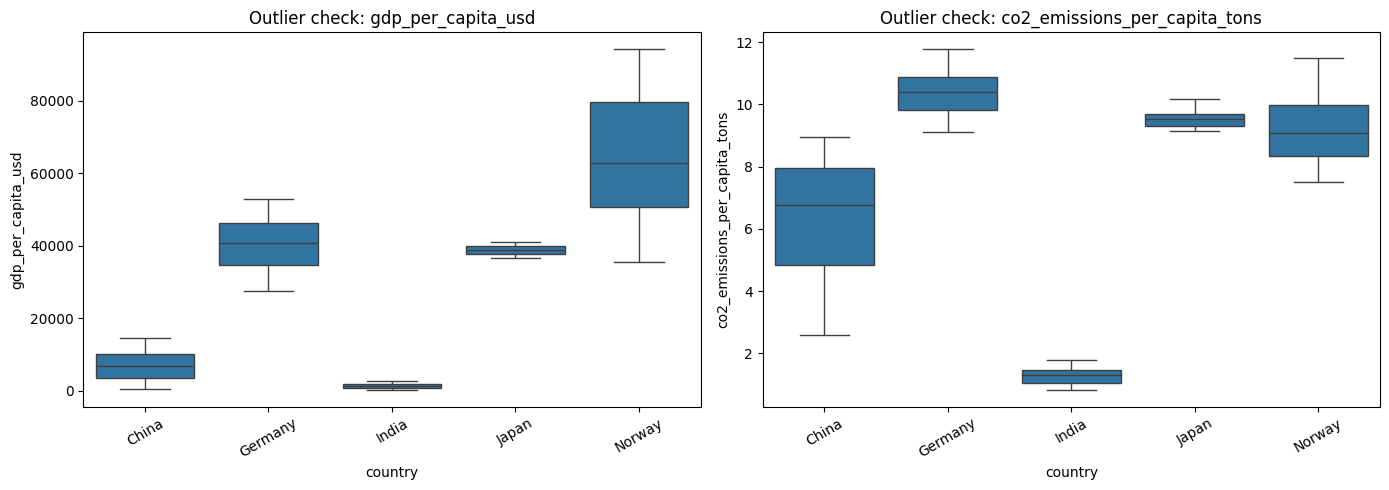


Boxplots saved as 'outlier_boxplots.png'.


In [10]:
print("\n--- Duplicate Check ---")
duplicate_count = df.duplicated().sum()
print(f"Number of fully duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

# Also check duplicate (country, year) combinations -- shouldn't repeat
dup_keys = df.duplicated(subset=["country", "year"]).sum()
print(f"Duplicate (country, year) pairs: {dup_keys}")


print("\n--- Outlier Check (IQR method) ---")

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in numeric_cols:
    outliers, low, high = detect_outliers_iqr(df, col)
    print(f"\nColumn: {col}")
    print(f"  Acceptable range: [{low:.2f}, {high:.2f}]")
    print(f"  Number of outliers detected: {len(outliers)}")
    if len(outliers) > 0:
        print(outliers[["country", "year", col]])

# Visualize outliers with boxplots (per country, per numeric column)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="country", y=col, ax=ax)
    ax.set_title(f"Outlier check: {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("outlier_boxplots.png", dpi=150)
plt.show()
print("\nBoxplots saved as 'outlier_boxplots.png'.")

 3. GDP² COLUMN CREATE CODE

In [13]:
df["gdp_per_capita_sq"] = df["gdp_per_capita_usd"] ** 2

print("\n--- GDP² Column Preview ---")
print(df[["country", "year", "gdp_per_capita_usd", "gdp_per_capita_sq"]].head())


--- GDP² Column Preview ---
  country  year  gdp_per_capita_usd  gdp_per_capita_sq
0   China  1994          611.262012       3.736412e+05
1   China  1995         1001.162108       1.002326e+06
2   China  1996         1408.422417       1.983654e+06
3   China  1997         1910.009994       3.648138e+06
4   China  1998         2294.856545       5.266367e+06


Save cleaned & preprocessed dataset

In [14]:
df.to_csv("cleaned_gdp_co2_dataset.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_gdp_co2_dataset.csv'.")
print("Final shape:", df.shape)


Cleaned dataset saved as 'cleaned_gdp_co2_dataset.csv'.
Final shape: (150, 5)
